# XGBoost - Modelo Aplicado a demanda energética Alemania (v2)

Aplicación del modelo XGBoost a la predicción valores de consumo de demanda energética en Alemania. Primero se importan las librerías requeridas

In [1]:

import xgboost

# procesamiento
import pandas as pd
import numpy as np
import holidays
import json

# ml, procesamiento
#import sklearn

from sklearn.model_selection import TimeSeriesSplit
#from sklearn.model_selection import train_test_split # no se requiere
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# optimización, warnings
import optuna
import warnings
import optuna.visualization as vis
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

# visual
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")

# semilla para reproductibilidad
# configuración de reproductbilidad
np.random.seed(42)
from optuna.samplers import TPESampler # reproductibilidad con optuna

c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Se cargan los valores de consumo a nivel semanal. La semana en este caso toma el primer día como lunes. Para ese lunes se muestra la demanda semanal promedio y se formatean las fechas en formato Date. El orden de las observaciones es $10^6$

In [2]:
date_close = pd.read_csv('../../../data/csv/EC_GER_Weekly.csv')
df_data_close = pd.DataFrame(date_close.copy()) # copia del df
df_data_close["Start date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close = df_data_close.sort_values(by="Start date", ascending=True)
df_data_close.head()

,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


Se grafican los datos de la serie a partir del dataframe anterior

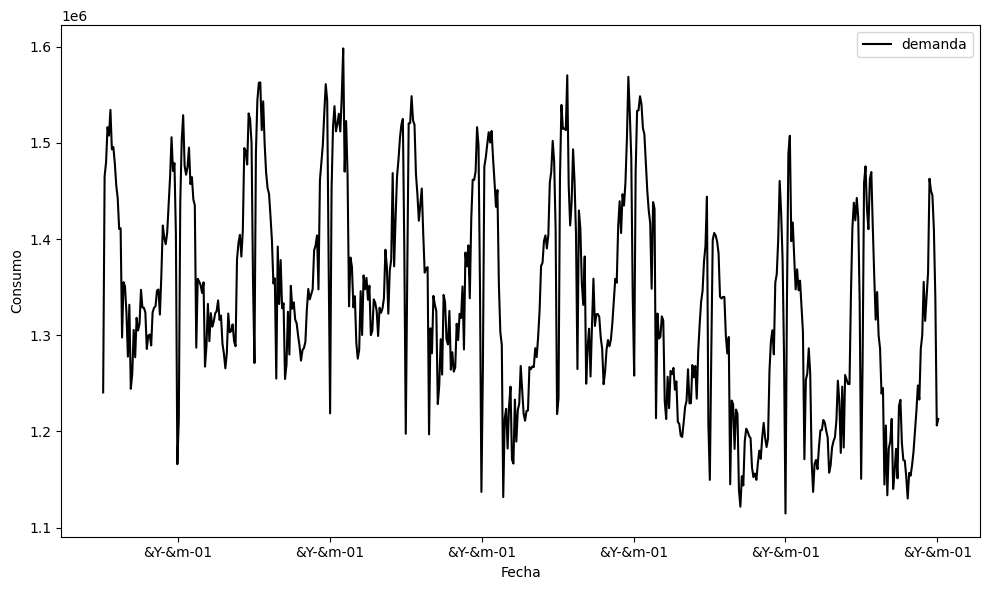

In [3]:
plt.figure(figsize=(10,6))
plt.plot(df_data_close["Start date"], df_data_close["value"], label="demanda", color="black")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# formateo de fechas en el eje x
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('&Y-&m-%d'))
plt.tight_layout()
plt.show()


se genera la partición preliminar trainf/testg, para determinar la fecha desde donde se toma el conjunto testf para la consistencia de este conjunto con los demás modelos

In [4]:
# se divide en train/test y se trabaja con train para el entrenamiento 
train_raw, test_raw = train_test_split(
    df_data_close,
    test_size=0.1,
    shuffle=False
)
train_raw = train_raw.sort_values(by="Start date")
test_raw = test_raw.sort_values(by="Start date")

# Fecha que define el inicio de TestF
fecha_train_test = test_raw["Start date"].iloc[0]

print("Train original:", len(train_raw))
print("TestF original:", len(test_raw))
print("Inicio TestF:", fecha_train_test)


Train original: 517
TestF original: 58
Inicio TestF: 2024-12-02 00:00:00


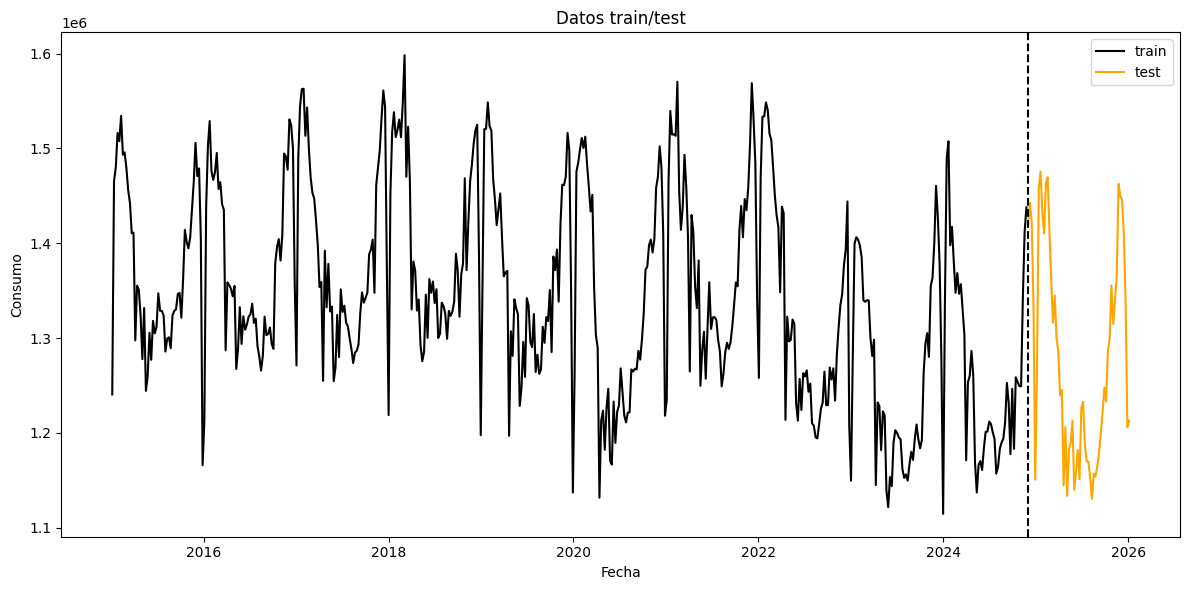

In [5]:
# gráfica train/test
plt.figure(figsize=(12,6))
plt.plot(train_raw["Start date"], train_raw["value"], label="train", color="black")
plt.plot(test_raw["Start date"], test_raw["value"], label="test", color="orange")
plt.axvline(fecha_train_test, color="black", linestyle="--")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()
plt.title("Datos train/test")
plt.tight_layout()
plt.show()

In [6]:
# en plotly
# asegurar que los índices sean fechas
train_raw.index = pd.to_datetime(train_raw.index)
test_raw.index = pd.to_datetime(test_raw.index)

# fecha de inicio de validación
fecha_inicio_val = test_raw.index.min()


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=train_raw["Start date"], y=train_raw["value"],
    mode="lines", name="train",
    line=dict(color="black", width=2)
))

fig.add_trace(go.Scatter(
    x=test_raw["Start date"], y=test_raw["value"],
    mode="lines", name="test",
    line=dict(color="orange", width=2)
))

fig.add_vline(
    x=fecha_train_test,
    line=dict(color="black", dash="dash", width=1)
)

fig.update_layout(
    title="Datos train/test",
    width=1200, height=600,
    template="plotly_white",
    margin=dict(l=60, r=30, t=50, b=60),
    plot_bgcolor="white", paper_bgcolor="white"
)

fig.update_xaxes(title="Fecha", tickformat="%Y-%m-%d",
                 showgrid=True, gridcolor="lightgray", automargin=True)
fig.update_yaxes(title="Consumo",
                 showgrid=True, gridcolor="lightgray", automargin=True)

fig.show()
fig.write_image(
    "../../../data/preds_energy_models/images/train_test_xgboost.png",
    width=1100,
    height=620,
    scale=3
)

Ahora se definen las variables: Se definen las variables generales a tener en cuenta en el df a partir de la fecha: temporalidades, rezagos y promedios

In [7]:
# función para obtener los valores de las variables año, mes y trimestre
def get_data_times(df, columnName):
    df_copy = df.copy()
    df_copy["year"] = df_copy[columnName].dt.year
    df_copy["month"] = df_copy[columnName].dt.month
    df_copy["quarter"] = df_copy[columnName].dt.quarter

    return df_copy


df_features = get_data_times(
    df_data_close,
    columnName="Start date"
)

Se definen los lags

In [8]:
# función para obtener los lags a partir de la columna start date
def make_df_full_lags(df, lags, variables):
    df_copy = df.copy()

    for variable in variables:
        for lag in lags:
            df_copy[f"{variable}_lag_{lag}"] = (
                df_copy[variable].shift(lag)
            )

    return df_copy


variables = ["value"]

lags = [1, 2, 3, 4, 8, 12, 52]

df_features = make_df_full_lags(
    df_features,
    lags=lags,
    variables=variables
)

Cálculo de medias móviles para diversos periodos, que funcionan como variables de entrada adicionales

In [9]:
# medias móviles de los precios de cierre: se crea una función para que tome las medias móviles de determinados
# días. Se toman estas medias moviles para los precios anteriores
def make_df_full_averages(
    df,
    vars_list,
    ma_periods,
    dropna=False,
    overwrite=False
):
    df_copy = df.copy()

    # solo se permiten las variables originales (sin _lag_ ni _ma_)
    clean_vars = [
        v for v in vars_list
        if v in df_copy.columns
        and "_lag_" not in v
        and "_ma_" not in v
    ]

    missing = [
        v for v in vars_list
        if v not in df_copy.columns # valida si las variables requeridas existen
    ]

    if missing:
        raise ValueError(
            f"Estas columnas no existen: {missing}"
        )

    for variable in clean_vars:
        for period in ma_periods:

            name = f"{variable}_ma_{period}" # nombre de columna para cálculo de MA de variable

            if (name in df_copy.columns) and (not overwrite):
                continue

            df_copy[name] = (
                df_copy[variable]
                .shift(1) # evita leakage, dado que se toma desde la posición t-1 hacia atras
                .rolling(window=period)
                .mean()
            )

    if dropna:
        df_copy = df_copy.dropna().reset_index(drop=True)

    return df_copy

ma_periods = [
    2, # dos semanas desde la anterior
    3, # tres semanas desde la anterior
    4, # 4 semanas desde la anterior (desde la ultima semana, un mes)
    8, # 8 semanas desde la anterior (desde la ultima semana, dos meses)
    12, # 12 semanas desde la anterior (desde la ultima semana, tres meses)
    16 # 16 semanas desde la anterior (desde la última semana, 4 meses)
]
df_features = make_df_full_averages(
    df_features,
    vars_list=variables,
    ma_periods=ma_periods,
    dropna=False
)

Ahora si, dado que hay variables en train que quedan con valores NA, se eliminan estos valores

In [10]:
# se eliminan variables con valor NA
df_features = (
    df_features
    .dropna()
    .reset_index(drop=True)
)

Ahora se definen los conjuntos trainG y testF finales

In [11]:
train = df_features[
    df_features["Start date"] < fecha_train_test
].copy()

test = df_features[
    df_features["Start date"] >= fecha_train_test
].copy()

Se definen los conjuntos de entrenamiento y test finales 

In [12]:
print("=== TRAIN XGBOOST ===")
print("Cantidad:", len(train))
print("Inicio:", train["Start date"].min())
print("Fin:", train["Start date"].max())

print("\n=== TEST XGBOOST ===")
print("Cantidad:", len(test))
print("Inicio:", test["Start date"].min())
print("Fin:", test["Start date"].max())

=== TRAIN XGBOOST ===
Cantidad: 465
Inicio: 2016-01-04 00:00:00
Fin: 2024-11-25 00:00:00

=== TEST XGBOOST ===
Cantidad: 58
Inicio: 2024-12-02 00:00:00
Fin: 2026-01-05 00:00:00


Se esquematizan los datos como un problema de aprendizaje supervisado: X es el array de features, y es el array de valores (columna value, que es la que se quiere predecir)

In [13]:
target = "value"

features = [
    col for col in df_features.columns
    if col not in ["value", "Start date"]
]

X_folds = (
    train
    .set_index("Start date")[features]
    .copy()
)

y_folds = (
    train
    .set_index("Start date")[target]
    .copy()
)

X_val = (
    test
    .set_index("Start date")[features]
    .copy()
)

y_val = (
    test
    .set_index("Start date")[target]
    .copy()
)

In [14]:
# dimensiones de los datasets de entrenamiento y prueba
print("X TrainG:", X_folds.shape)
print("y TrainG:", y_folds.shape)

print("X TestF:", X_val.shape)
print("y TestF:", y_val.shape)

X TrainG: (465, 16)
y TrainG: (465,)
X TestF: (58, 16)
y TestF: (58,)


In [15]:
# validación cantidad de observaciones en los conjuntos:
assert len(X_val) == 58
assert len(y_val) == 58

assert X_folds.index.max() < X_val.index.min()

### Creación de Folds
Para el conjunto de datos X_Folds se definen una serie de "particiones" que ayudarán a determinar si el modelo encontrado se ajusta de forma consistente en diversas franjas de tiempo, ayudando a evitar inferir correlaciones espurias 

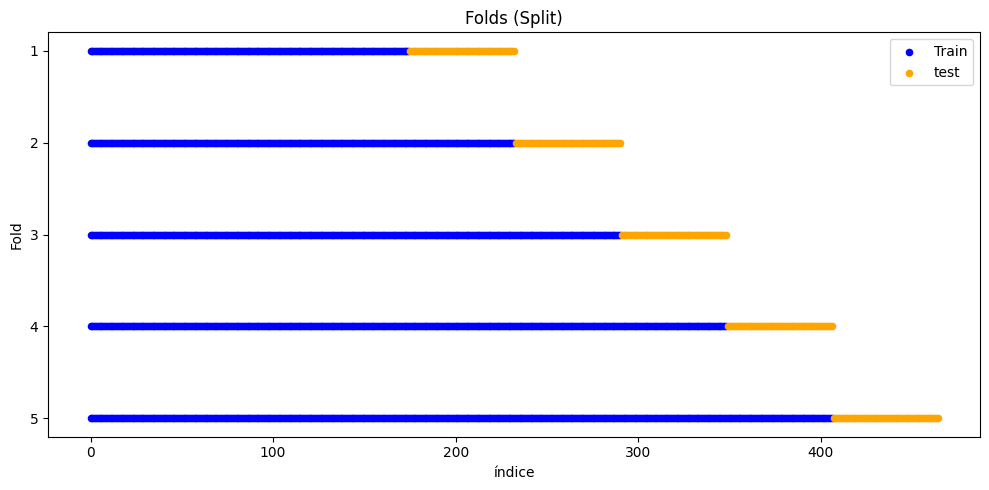

In [16]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
size_test = int(len(X_val))
gap = 0 # distancia (cantidad de observaciones) que se deja entre train y test
n_splits = 5 # cantidad de folds
tscv = TimeSeriesSplit(
    n_splits=n_splits,
    test_size=size_test, 
)

folds, indexes, types = [], [], []
fig, ax = plt.subplots(figsize=(10,5))
for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_folds)):
    # datos de entrenamiento
    fold_plot = fold_idx + 1
    ax.scatter(
        train_idx,
        [fold_plot] * len(train_idx),
        label="Train" if fold_idx == 0 else '',
        s=20, 
        color="blue"
    )
    # datos de prueba

    ax.scatter(
        test_idx,
        [fold_plot] * len(test_idx),
        label="test" if fold_idx == 0 else '',
        s=20,
        color="orange"
    )

ax.set_title("Folds (Split)")
ax.set_xlabel("índice")
ax.set_ylabel("Fold")

# invertir eje
#ax.invert_xaxis()
ax.legend()
ax.set_yticks(range(1, n_splits + 1))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Función para instanciar el modelo

In [17]:
# función de creación del modelo 
def build_xgboost_regressor(**params):
    # puedes establecer valores por defecto si faltan
    params.setdefault("objective", "reg:squarederror")
    params.setdefault("tree_method", "exact")
    params.setdefault("random_state", 42)

    model = xgboost.XGBRegressor(**params)
    return model


# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo XGBoost con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


In [18]:
# validación tamaños conjuntos folds / val
print(f"cantidad datos folds: {len(X_folds)}")
print(f"cantidad datos val: {len(X_val)}")

cantidad datos folds: 465
cantidad datos val: 58


validacion previa: se examina que conjuntos train y test de los folds no compartan valores, para evitar data leakage. Se valida que el último índice del conjunto de entrenamiento mas el gap definido antes no sea mayor o igual que el primer índice del conjunto de test de cada fold, así se valida que no hay solapamiento de datos 

In [19]:
# se toma el último índice del conjunto de indices train de cada fold, se suma el gap y se compara con el primer índice del conjunto de pruebas
# de cada fold
for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_folds)):
    print(f"último índice de train de fold {fold_idx} + gap: {train_idx[-1] + gap}. Primer indice de test de fold {fold_idx}: {test_idx[0]}")

último índice de train de fold 0 + gap: 174. Primer indice de test de fold 0: 175
último índice de train de fold 1 + gap: 232. Primer indice de test de fold 1: 233
último índice de train de fold 2 + gap: 290. Primer indice de test de fold 2: 291
último índice de train de fold 3 + gap: 348. Primer indice de test de fold 3: 349
último índice de train de fold 4 + gap: 406. Primer indice de test de fold 4: 407


In [20]:
def objective(trial):
    # Parámetros del modelo
    #lag = trial.suggest_categorical("lag", [1, 2, 7, 15, 30, 90])
    params = {
        # cantidad arboles
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        # profundidad de cada arbol
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        # tasa de aprendizaje
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        # longitud minima
        "min_child_weight": trial.suggest_float("min_child_weight", 5.0, 15.0),
        # umbral de ganancia
        "gamma": trial.suggest_float("gamma", 1e-3, 1.0),
        # parametro de regresión
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0),
        #parametro de regresión
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 5.0),
        # cantidad de datos para la creación de los árboles
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        # función objetivo
        "objective": "reg:squarederror",
        # metodo de creación de particiones
        "tree_method": "exact",
        # semilla para reproductibilidad
        "random_state": 42,
        "nthread":1
    }

    # Métricas a recolectar
    mapes, maes, rmses, smapes, variables = [], [], [], [], []
    importancias_por_fold = []

    # Validación cruzada temporal
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_folds)):
        variables = {}

        # División train/test (sin escalado)
        X_train, X_test = X_folds.iloc[train_idx], X_folds.iloc[test_idx]
        y_train = y_folds.iloc[train_idx].values
        y_test  = y_folds.iloc[test_idx].values

        
        # Entrenamiento, prediccion y metricas 
        model = build_xgboost_regressor(**params)
        model.fit(
            X_train, 
            y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        #Predicciones
        y_pred = model.predict(X_test)

        # Métricas de error
        mae  = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        smape_calc = MeanAbsolutePercentageError(symmetric=True) 
        smape = smape_calc(y_test, y_pred)

        # almacenado en arrays
        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)
        smapes.append(smape)


        # almacenado - variables de importancia
        booster = model.get_booster()
        score = booster.get_score(importance_type='gain') # puntaje por ganancia, definicion

        # validar que se encuentren todas las variables
        score_full = {col: score.get(col, 0.0) for col in X_train.columns}

        # se normalizan las variables
        total = sum(score_full.values())
        if total > 0:
            score_norm = {k: v / total for k, v in score_full.items()}
        else:
            score_norm = score_full

        importancias_por_fold.append(score_norm)

        #for i  in range(len(X_train.columns)):
        #    variables[X.columns[i]] = model.feature_importances_[i]

        # Registro 
        trial.set_user_attr(f"fold_{fold_idx + 1}", {
            "mae": mae,
            "mape": mape,
            "rmse": rmse, 
            "smape": smape,
            f"importancia_variables_fold_{fold_idx + 1}": score_norm

        })
        # reporte métrica a optimizar
        trial.report(np.mean(mapes), step=fold_idx)

   
    # Función objetivo
    mean_mape = np.mean(mapes)
    median_mape = np.median(mapes)
    mean_smape = np.mean(smapes)
    mean_rmse = np.mean(rmses)
    mean_mae = np.mean(maes)

    df_importance = pd.DataFrame(importancias_por_fold)

    importance_mean = df_importance.mean().to_dict()
    trial.set_user_attr("importance_mean", importance_mean)

    
    # configuración atributos de usuario
    trial.set_user_attr("mape_mean", mean_mape)
    trial.set_user_attr("mape_median", median_mape)
    trial.set_user_attr("mae_mean", mean_mae)
    trial.set_user_attr("rmse_mean", mean_rmse)
    trial.set_user_attr("smape_mean", mean_smape)
    
    
    return float(mean_mape) 

print("Optimización con Optuna en curso...")
study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, n_jobs=1)
best_params = study.best_params
print("Mejores parámetros encontrados:\n", best_params)

[I 2026-09-24 23:17:13,697] A new study created in memory with name: no-name-b29832a7-47f7-4cf2-9639-123844041452


Optimización con Optuna en curso...


[I 2026-09-24 23:17:25,148] Trial 0 finished with value: 0.03855872302794906 and parameters: {'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.07587945476302646, 'min_child_weight': 10.986584841970366, 'gamma': 0.1568626218019941, 'reg_lambda': 0.864373149647393, 'reg_alpha': 0.38460969962417735, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835}. Best is trial 0 with value: 0.03855872302794906.
[I 2026-09-24 23:17:29,115] Trial 1 finished with value: 0.0363798542800061 and parameters: {'n_estimators': 483, 'max_depth': 3, 'learning_rate': 0.0972918866945795, 'min_child_weight': 13.324426408004218, 'gamma': 0.21312677156759788, 'reg_lambda': 0.990942339314793, 'reg_alpha': 0.9986820982818257, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951}. Best is trial 1 with value: 0.0363798542800061.
[I 2026-09-24 23:17:32,850] Trial 2 finished with value: 0.036140150944356894 and parameters: {'n_estimators': 373, 'max_depth': 4, 'learning_rate'

Mejores parámetros encontrados:
 {'n_estimators': 226, 'max_depth': 8, 'learning_rate': 0.018538556541445407, 'min_child_weight': 14.303227994821025, 'gamma': 0.7790775142791473, 'reg_lambda': 1.8922333265119773, 'reg_alpha': 4.787041747916226, 'subsample': 0.7482850768233147, 'colsample_bytree': 0.6249899964700355}


Se extraen los resultados del mejor trial

In [21]:
# Extraer resultados del mejor trial
best_trial = study.best_trial
print("Mejor trial:", best_trial.number)
print("MAPE promedio:", best_trial.value)
print("Atributos guardados:")
print(best_trial.user_attrs)


Mejor trial: 42
MAPE promedio: 0.033384271067233295
Atributos guardados:
{'fold_1': {'mae': 46981.59913793104, 'mape': 0.03777835948973319, 'rmse': 67289.68982166133, 'smape': 0.036325096536241434, 'importancia_variables_fold_1': {'year': 0.0046321214385349205, 'month': 0.059075775605816595, 'quarter': 0.08686221654041125, 'value_lag_1': 0.16413558975859197, 'value_lag_2': 0.016608219530945316, 'value_lag_3': 0.01361430261462173, 'value_lag_4': 0.0133902328564627, 'value_lag_8': 0.021536619742994912, 'value_lag_12': 0.012298642653280617, 'value_lag_52': 0.30607768257313966, 'value_ma_2': 0.10109962945697572, 'value_ma_3': 0.04649969023198674, 'value_ma_4': 0.09640339708912783, 'value_ma_8': 0.021583886696598137, 'value_ma_12': 0.01900934422012854, 'value_ma_16': 0.017172648990383343}}, 'fold_2': {'mae': 35857.47321428571, 'mape': 0.02617468104379425, 'rmse': 46472.34443310789, 'smape': 0.026568920949588654, 'importancia_variables_fold_2': {'year': 0.03583580608148522, 'month': 0.034521

Se extraen los datos de asignación de puntaje de variables para elxaminar la asignación de importancia a nivel general y por fold

In [22]:
# df de comportamiento de variables
rows = []

for i in range(n_splits):
    fold_key = f"fold_{i+1}"
    imp_key = f"importancia_variables_fold_{i+1}"

    for var, val in best_trial.user_attrs[fold_key][imp_key].items():
        rows.append({
            "variable": var,
            "fold": i + 1,
            "importancia": val
        })

df_importancias = pd.DataFrame(rows)
df_importancias

,variable,fold,importancia
0,year,1,0.004632
1,month,1,0.059076
2,quarter,1,0.086862
3,value_lag_1,1,0.164136
4,value_lag_2,1,0.016608
...,...,...,...
75,value_ma_3,5,0.154926
76,value_ma_4,5,0.077591
77,value_ma_8,5,0.036762
78,value_ma_12,5,0.021347


In [23]:
df_resumen = (
    df_importancias
    .groupby("variable")["importancia"]
    .agg(["mean"])
    .round(4)
    .sort_values(by="mean", ascending=False)
    .reset_index()
)
df_resumen

,variable,mean
0,value_lag_52,0.3115
1,value_lag_1,0.1780
2,value_ma_2,0.1044
3,value_ma_3,0.0860
4,value_ma_4,0.0650
5,quarter,0.0479
6,month,0.0363
7,value_ma_8,0.0268
8,value_lag_8,0.0195
9,value_ma_12,0.0187


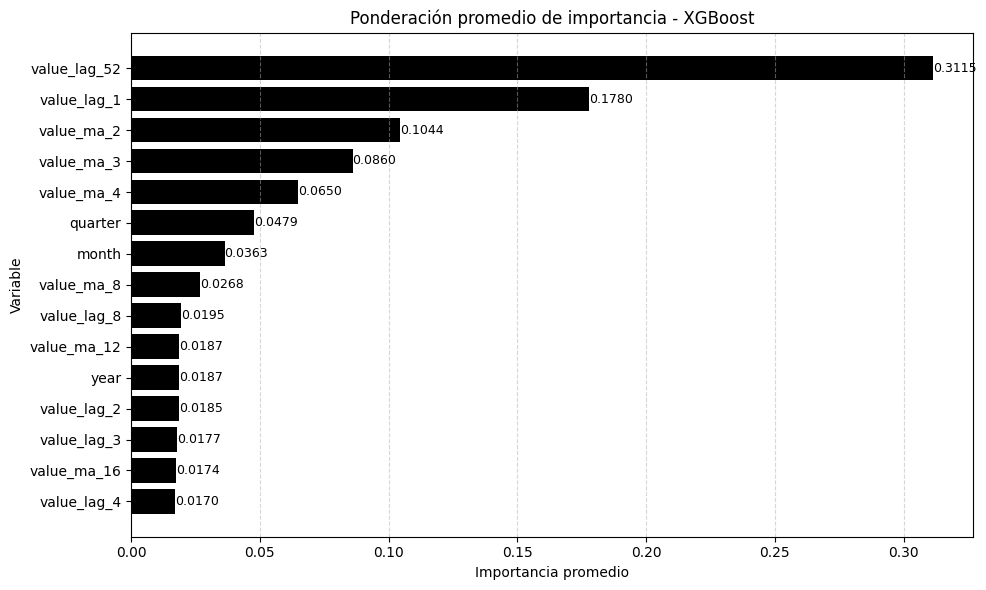

In [24]:
# Estadísticas promedio por variable
df_hist_avg_vars = (
    df_importancias
        .groupby("variable", as_index=False)["importancia"]
        .mean()
        .sort_values("importancia", ascending=False)
)

# filtrar importancia estrictamente positiva
df_hist_avg_vars = df_hist_avg_vars[df_hist_avg_vars["importancia"] > 0]

# opcional: tomar top 15 para que el gráfico sea legible (cantidad de variables)
top_k = 15
df_plot = df_hist_avg_vars.head(top_k)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_plot["variable"], df_plot["importancia"], color="black")

# agregar valores numéricos al lado de cada barra
for i, v in enumerate(df_plot["importancia"]):
    plt.text(v, i, f"{v:.4f}", va="center", fontsize=9)

plt.gca().invert_yaxis()
plt.title("Ponderación promedio de importancia - XGBoost")
plt.xlabel("Importancia promedio")
plt.ylabel("Variable")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


AAhora se muestra la asignación de los puntajes e importancia por fold

In [25]:
# matriz de importancias por fold
df_stats_by_folds = []

for i in range(n_splits):

    df_fold = df_importancias[
        (df_importancias["fold"] == i+1) &
        (df_importancias["importancia"] > 0.00)
    ]

    df_fold_matrix = (
        df_fold
        .pivot_table(
            index="fold",
            columns="variable",
            values="importancia",
            aggfunc="sum"
        )
        .reset_index()
    )

    df_stats_by_folds.append(df_fold_matrix)

# unir todos los folds
df_stats_by_folds = pd.concat(df_stats_by_folds, ignore_index=True)
df_stats_by_folds

variable,fold,month,quarter,value_lag_1,value_lag_12,value_lag_2,value_lag_3,value_lag_4,value_lag_52,value_lag_8,value_ma_12,value_ma_16,value_ma_2,value_ma_3,value_ma_4,value_ma_8,year
0,1,0.059076,0.086862,0.164136,0.012299,0.016608,0.013614,0.013390,0.306078,0.021537,0.019009,0.017173,0.101100,0.046500,0.096403,0.021584,0.004632
1,2,0.034522,0.032973,0.192100,0.021234,0.017174,0.020499,0.020582,0.308149,0.022057,0.024257,0.016061,0.110406,0.095475,0.027559,0.021116,0.035836
2,3,0.029445,0.056307,0.158906,0.017706,0.018835,0.018822,0.020383,0.344986,0.019709,0.015093,0.017424,0.143232,0.060755,0.041702,0.021397,0.015298
3,4,0.035476,0.044620,0.185852,0.017509,0.021335,0.019380,0.015735,0.334371,0.015215,0.013967,0.017098,0.082644,0.072226,0.081596,0.032933,0.010042
4,5,0.022826,0.018738,0.188777,0.014970,0.018739,0.016104,0.014747,0.263729,0.018802,0.021347,0.019315,0.084780,0.154926,0.077591,0.036762,0.027843


Se grafican los resultados y las asignaciones de puntaje por folds

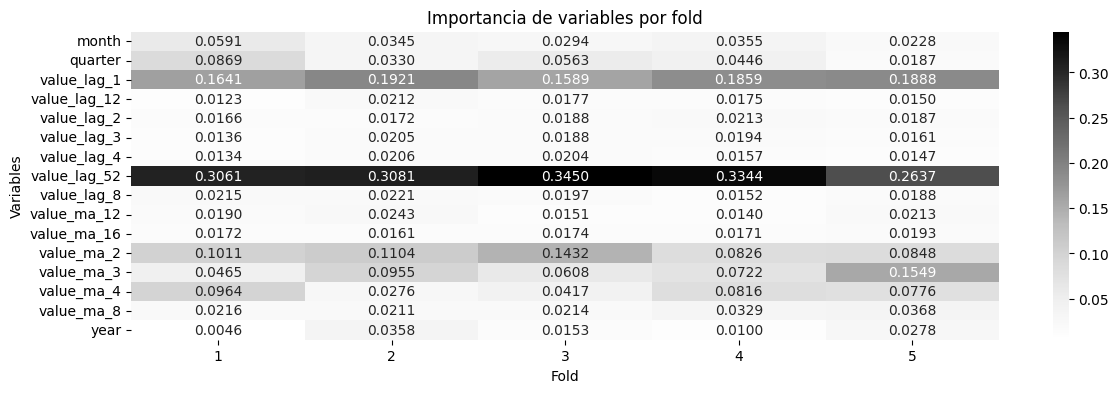

In [26]:

df_plot = df_stats_by_folds.set_index("fold")

plt.figure(figsize=(14,4))
sns.heatmap(df_plot.T, cmap="Greys", annot=True, fmt=".4f")
plt.title("Importancia de variables por fold")
plt.xlabel("Fold")
plt.ylabel("Variables")
plt.show()

Se organiza el df para que muestre lo spuntajes por fold como gráficas de barras

In [27]:
df_long = df_stats_by_folds.melt(
    id_vars=["fold"], 
    var_name="variable", 
    value_name="importancia"
).sort_values(by=["fold", "importancia"], ascending=[True, False])
df_long.head()

,fold,variable,importancia
35,1,value_lag_52,0.306078
10,1,value_lag_1,0.164136
55,1,value_ma_2,0.101100
65,1,value_ma_4,0.096403
5,1,quarter,0.086862


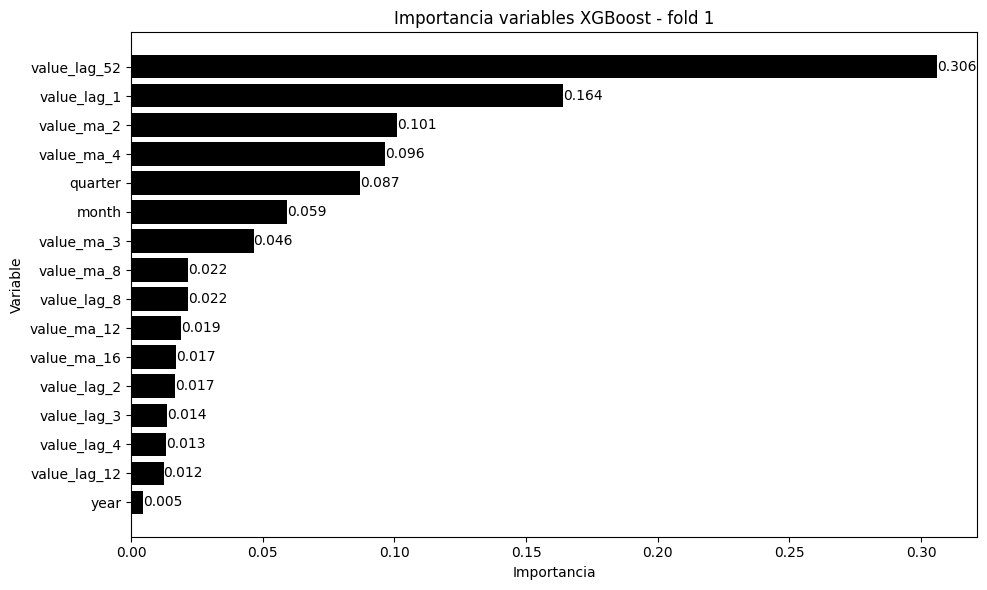

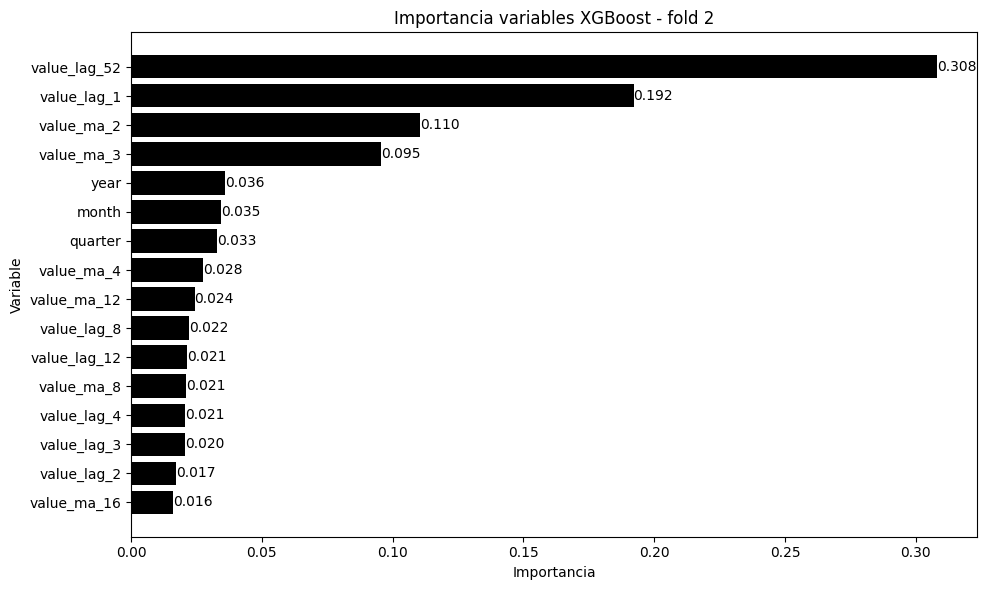

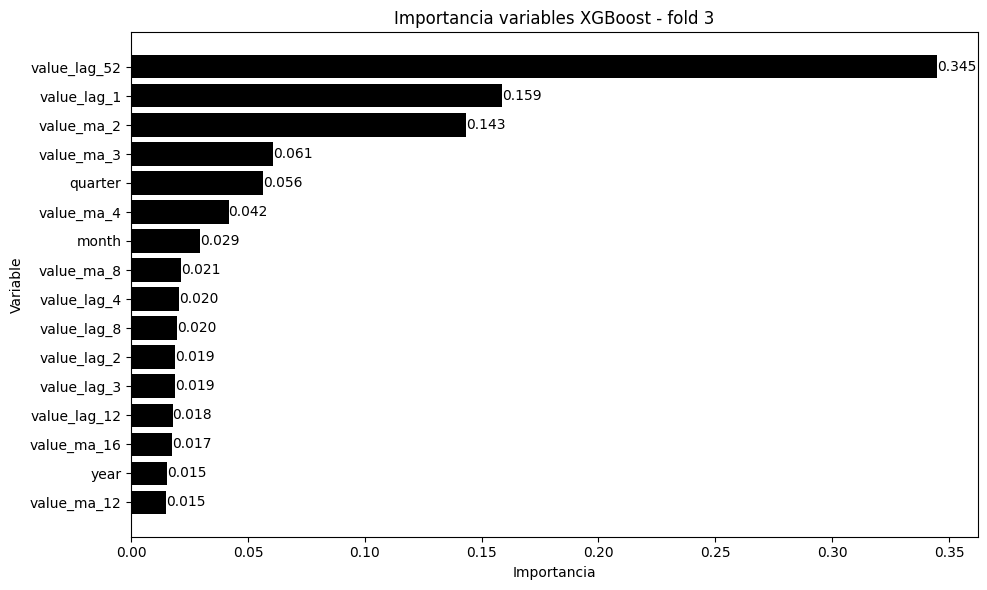

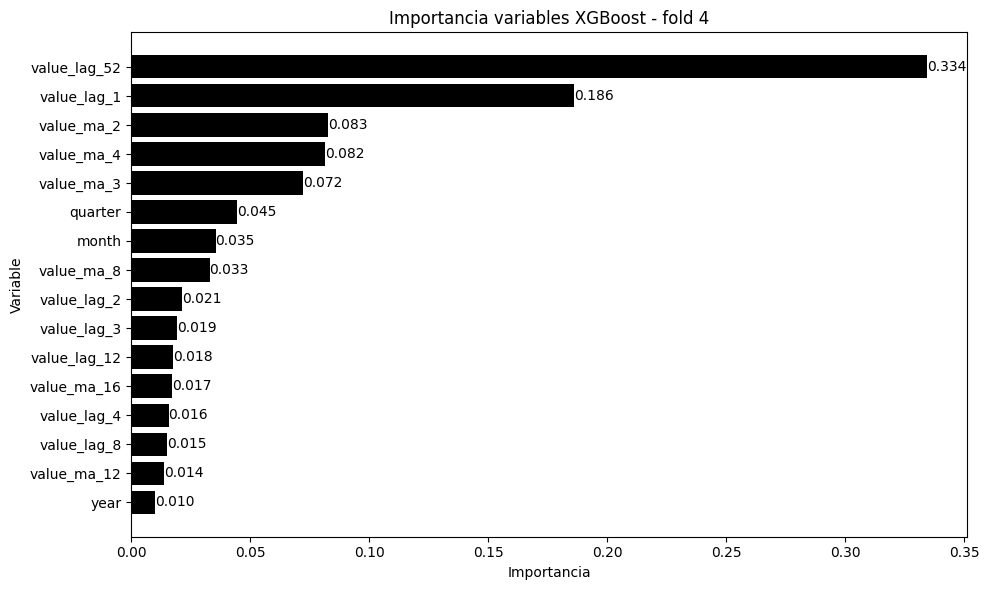

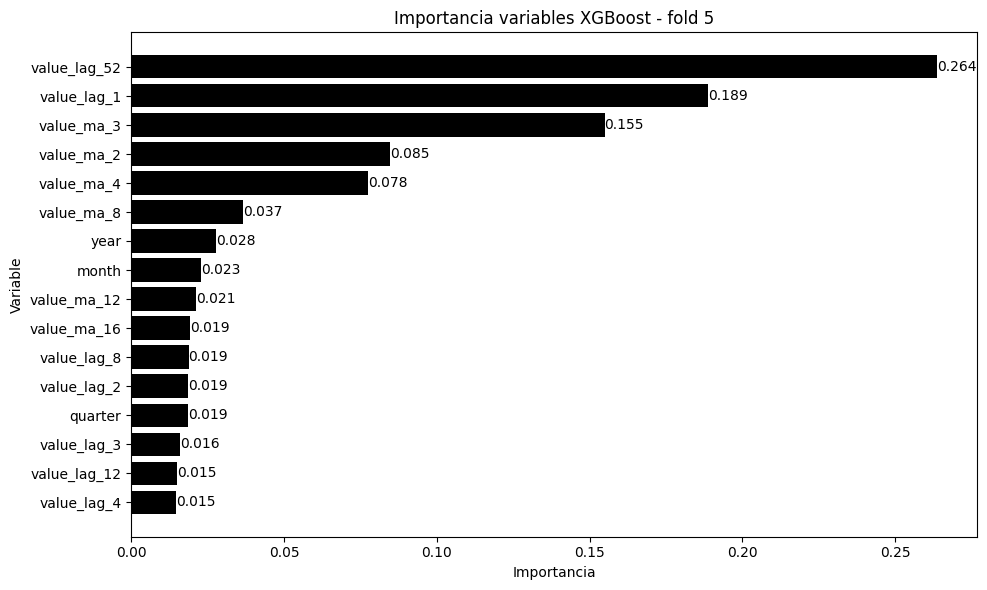

In [28]:
for fold in df_long["fold"].unique():
    df_fold = df_long[df_long["fold"] == fold]
    
    plt.figure(figsize=(10,6))
    bars = plt.barh(df_fold["variable"], df_fold["importancia"], color="black")
    plt.gca().invert_yaxis()
    
    plt.title(f"Importancia variables XGBoost - fold {fold}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")

    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center")

    plt.tight_layout()
    plt.show()

se obtiene todo el listado de los trials ejecutados y se crea un df que muestra los errores por fold y por trial

In [29]:

# info de los trials 
# se extraen los trials
trials = study.get_trials()
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas en cada registro (las claves no varían, dado como se guardaron)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": int(key.replace("fold_", "")),   # extraer número
                "mape": value["mape"],
                "mae": value["mae"],
                "rmse": value["rmse"],
                "smape": value["smape"]
            })

df_metrics = pd.DataFrame(rows)
df_metrics.head()


,trial,fold,mape,mae,rmse,smape
0,0,1,0.039981,49952.524015,70427.263784,0.038409
1,0,2,0.038325,52401.397167,67645.340902,0.039533
2,0,3,0.020658,27396.472599,38061.101005,0.020505
3,0,4,0.054243,67148.241995,83595.596567,0.052083
4,0,5,0.039588,51640.575739,66544.857502,0.040192


In [30]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse", "smape"]]

,mape,mae,rmse,smape
count,250.000000,250.000000,250.000000,250.000000
mean,0.035276,45449.183526,60791.197479,0.034848
std,0.009348,10917.513611,13170.199237,0.008843
min,0.019366,25577.839594,35909.165352,0.019187
25%,0.027197,37335.991379,48867.719574,0.027669
50%,0.037575,47922.197352,65535.620458,0.036933
75%,0.039574,51631.636161,69613.597786,0.040076
max,0.054243,67148.241995,85651.125685,0.052083


### Distribución por errores promedio
se muestran las distribuciones de los errores promedio por trial

In [31]:
df_metrics_avg = df_metrics.copy()
df_metrics_avg = df_metrics_avg.groupby(
    "trial", as_index=False 
)[["mape", "mae", "rmse", "smape"]].mean()
df_metrics_avg.head()

,trial,mape,mae,rmse,smape
0,0,0.038559,49707.842303,65254.831952,0.038144
1,1,0.036380,46958.106527,62905.667756,0.035948
2,2,0.036140,46572.152894,61924.674264,0.035806
3,3,0.037687,48710.756650,65422.920871,0.037270
4,4,0.036946,47695.836761,63934.834466,0.036547


In [32]:
# minimos y máximos de métricas promedio  
print(f"mape_prom minimo: {round(df_metrics_avg['mape'].min(), 4)}, mape_prom max: {round(df_metrics_avg['mape'].max(), 4)}")
print(f"mae_prom minimo: {round(df_metrics_avg['mae'].min(), 4)}, mae_prom max: {round(df_metrics_avg['mae'].max(), 4)}")
print(f"rmse_prom minimo: {round(df_metrics_avg['rmse'].min(), 4)}, rmse_prom max: {round(df_metrics_avg['rmse'].max(), 4)}")
print(f"smape_prom minimo: {round(df_metrics_avg['smape'].min(), 4)}, smape_prom max: {round(df_metrics_avg['smape'].max(), 4)}")

mape_prom minimo: 0.0334, mape_prom max: 0.039
mae_prom minimo: 42901.1704, mae_prom max: 50276.3514
rmse_prom minimo: 57580.8405, rmse_prom max: 65894.4261
smape_prom minimo: 0.0329, smape_prom max: 0.0387


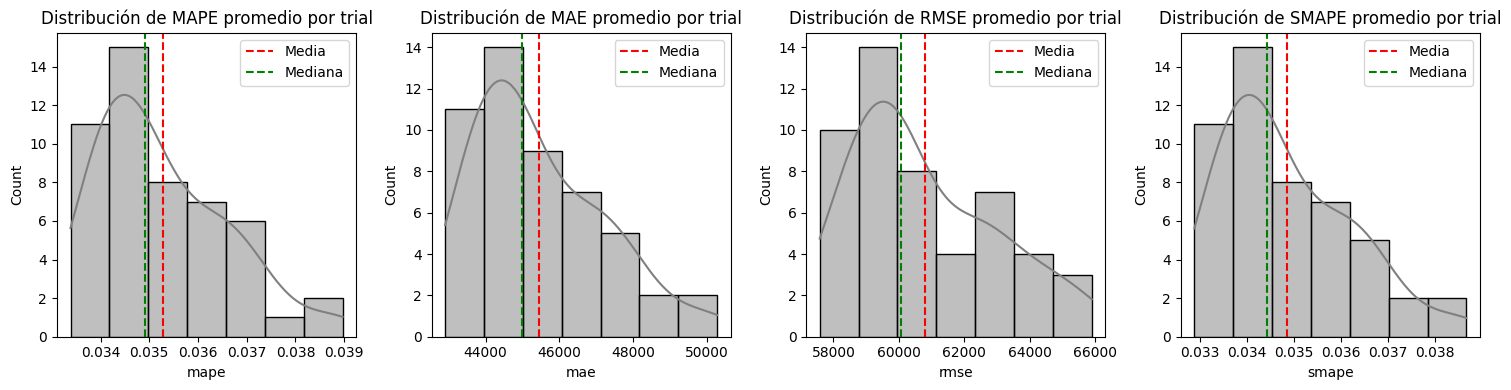

In [33]:
# distribución errores promedio por fold
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics_avg[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()} promedio por trial")
    ax.axvline(df_metrics_avg[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics_avg[metric].median(), color='green', linestyle='--', label='Mediana')
    ax.legend()

plt.tight_layout()
plt.show()

### Distribución de errores por fold y por trial
se muestran los valores de las métricas de error por cada fold y por cada trial

In [34]:
# minimos y máximos de métricas por fold  
print(f"mape_fold minimo: {round(df_metrics['mape'].min(), 4)}, mape_fold max: {round(df_metrics['mape'].max(), 4)}")
print(f"mae_fold minimo: {round(df_metrics['mae'].min(), 4)}, mae_fold max: {round(df_metrics['mae'].max(), 4)}")
print(f"rmse_fold minimo: {round(df_metrics['rmse'].min(), 4)}, rmse_fold max: {round(df_metrics['rmse'].max(), 4)}")
print(f"smape_fold minimo: {round(df_metrics['smape'].min(), 4)}, smape_fold max: {round(df_metrics['smape'].max(), 4)}")

mape_fold minimo: 0.0194, mape_fold max: 0.0542
mae_fold minimo: 25577.8396, mae_fold max: 67148.242
rmse_fold minimo: 35909.1654, rmse_fold max: 85651.1257
smape_fold minimo: 0.0192, smape_fold max: 0.0521


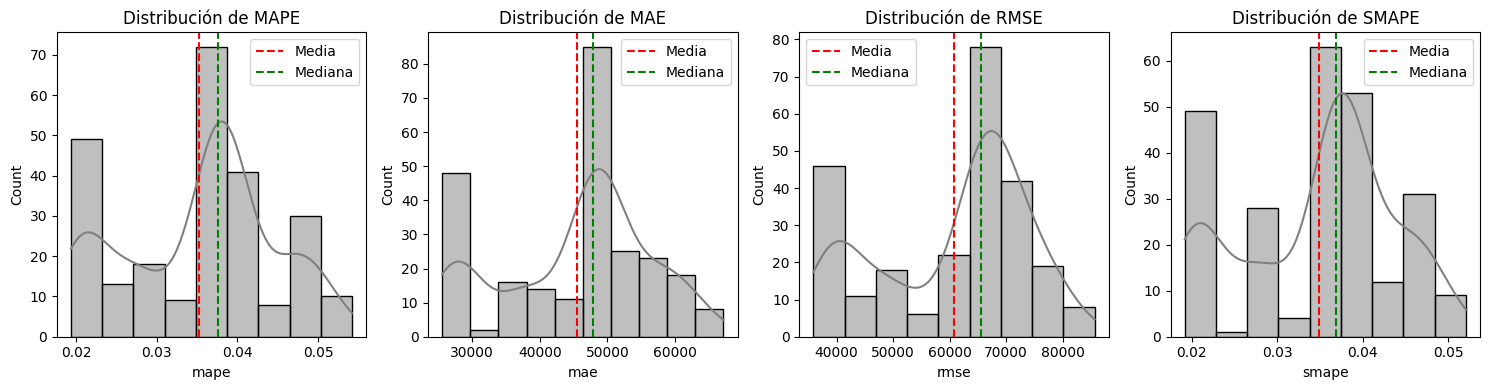

In [35]:
# histogramas de los errores por trial y por fold
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    """ if metric == 'mape':
        medians_df['mape'] = df_metrics[metric].median() """
    ax.legend()

plt.tight_layout()
plt.show()


Se ordena por métrica 

In [36]:
# Ordenar por cada métrica para tomar los mejores conjuntos de parametros
df_mape_sorted = df_metrics.sort_values("mape", ascending=True).reset_index(drop=True)
df_mae_sorted = df_metrics.sort_values("mae", ascending=True).reset_index(drop=True)
df_rmse_sorted = df_metrics.sort_values("rmse", ascending=True).reset_index(drop=True)
df_smape_sorted = df_metrics.sort_values("smape", ascending=True).reset_index(drop=True)

print("Mejores Folds por MAPE:")
print(df_mape_sorted.tail())

print("\Mejores Folds por MAE:")
print(df_mae_sorted.tail())

print("\Mejores Folds por RMSE:")
print(df_rmse_sorted.tail())

print("\Mejores Folds por sMAPE:")
print(df_smape_sorted.tail())

Mejores Folds por MAPE:
     trial  fold      mape           mae          rmse     smape
245     28     4  0.052109  63976.636084  78764.336192  0.050121
246     20     4  0.052111  64482.536330  80713.412383  0.050102
247     40     4  0.052266  64945.301416  82085.331758  0.050211
248      3     4  0.053324  66487.752771  85651.125685  0.051096
249      0     4  0.054243  67148.241995  83595.596567  0.052083
\Mejores Folds por MAE:
     trial  fold      mape           mae          rmse     smape
245     28     4  0.052109  63976.636084  78764.336192  0.050121
246     20     4  0.052111  64482.536330  80713.412383  0.050102
247     40     4  0.052266  64945.301416  82085.331758  0.050211
248      3     4  0.053324  66487.752771  85651.125685  0.051096
249      0     4  0.054243  67148.241995  83595.596567  0.052083
\Mejores Folds por RMSE:
     trial  fold      mape           mae          rmse     smape
245      8     4  0.050843  63285.794951  81072.573740  0.048857
246      5     4 

Se crea df que obtiene los hiperparametros por fold junto con las metricas asociadas, se toman los 3 que dejan menor mape promedio para comparar y luego se toma uno solo

In [37]:
df_trials = {   
    "trial" :[],
    "n_estimators": [],
    "max_depth": [],
    "learning_rate": [],
    "min_child_weight": [] ,
    "gamma": [],
    "reg_lambda" : [],
    "reg_alpha" : [],
    "subsample" : [],
    "colsample_bytree": [],
    "mape_mean": [],
    "mae_mean": [],
    "rmse_mean": [],
    "smape_mean": []
}

for trial in trials:
    for key in df_trials.keys():

        if key == "trial":
            df_trials[key].append(trial.number)

        elif key in ["mape_mean", "mae_mean", "rmse_mean", "smape_mean"]:
            df_trials[key].append(round(trial.user_attrs[key],6))

        else: 
            df_trials[key].append(round(trial.params[key],5))
   
df_params_models = pd.DataFrame(df_trials)
df_params_models = df_params_models.sort_values("mape_mean") # se ordenan conjuntos de hiperparametros que dejan menor mape promedio y se toma
# el menor
df_params_models.head(3)

,trial,n_estimators,max_depth,learning_rate,min_child_weight,gamma,reg_lambda,reg_alpha,subsample,colsample_bytree,mape_mean,mae_mean,rmse_mean,smape_mean
42,42,226,8,0.01854,14.30323,0.77908,1.89223,4.78704,0.74829,0.62499,0.033384,42901.170443,57580.840547,0.032890
44,44,241,8,0.02360,13.30150,0.81959,1.54242,4.77237,0.75206,0.62381,0.033685,43376.492672,58124.429053,0.033229
41,41,235,8,0.01620,13.98789,0.81758,2.19918,4.85376,0.74313,0.67333,0.033760,43373.391749,58166.252956,0.033248


In [38]:
# se exporta el df con los mejores modelos 
df_params_models.head(3).to_csv("../../../data/best_train_models/best_models_xgboost_v2.csv")

In [39]:
# organización de hiperparametros
# Corrección
params_xgb = {
    k: v 
    for k, v in study.best_params.items() 
    if k != 'lag'
}
study.best_params

# La variable params_xgb contendrá solo los hiperparámetros de XGBoost
# (n_estimators, max_depth, learning_rate, etc.),

{'n_estimators': 226,
 'max_depth': 8,
 'learning_rate': 0.018538556541445407,
 'min_child_weight': 14.303227994821025,
 'gamma': 0.7790775142791473,
 'reg_lambda': 1.8922333265119773,
 'reg_alpha': 4.787041747916226,
 'subsample': 0.7482850768233147,
 'colsample_bytree': 0.6249899964700355}

In [40]:
len(X_val)

58

In [41]:
# se fija el modelo con los mejores hiperparametros con los datos finales, se hacen la prediccione y se examinan los errores oos
best_model = build_xgboost_regressor(**params_xgb, nthreads=1)
best_model.fit(X_folds, y_folds)
y_pred = best_model.predict(X_val)

# metricas de error 

mape_val = mean_absolute_percentage_error(y_val, y_pred)
mae_val  = mean_absolute_error(y_val, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred))
smape_calc_val = MeanAbsolutePercentageError(symmetric=True) 
smape_val = smape_calc_val(y_val, y_pred)

print(f"mape validación: {mape_val*100:.4f}%")
print(f"mae validación: {mae_val}")
print(f"rmse validación: {rmse_val}")
print(f"smape validación: {smape_val*100:.4f}")

mape validación: 2.7664%
mae validación: 35317.64760262724
rmse validación: 47089.46813946579
smape validación: 2.7528


In [42]:

importance = best_model.get_booster().get_score(importance_type="gain")

total = sum(importance.values())

importance_norm = {k: v / total for k, v in importance.items()}

importance_norm

{'year': 0.022345032829801662,
 'month': 0.024678795857194787,
 'quarter': 0.024691056618232864,
 'value_lag_1': 0.19909685920934717,
 'value_lag_2': 0.01829788776470101,
 'value_lag_3': 0.015593436739572957,
 'value_lag_4': 0.01372451629856155,
 'value_lag_8': 0.020506273198796606,
 'value_lag_12': 0.017605779667574404,
 'value_lag_52': 0.2721940377226813,
 'value_ma_2': 0.10636034731491499,
 'value_ma_3': 0.08751917733802815,
 'value_ma_4': 0.10334243437338678,
 'value_ma_8': 0.03727896257098933,
 'value_ma_12': 0.022736589503614894,
 'value_ma_16': 0.01402881299260156}

In [43]:
y_folds

Start date
2016-01-04    1.213233e+06
2016-01-11    1.437911e+06
2016-01-18    1.502718e+06
2016-01-25    1.528752e+06
2016-02-01    1.475937e+06
                  ...     
2024-10-28    1.249367e+06
2024-11-04    1.249165e+06
2024-11-11    1.343063e+06
2024-11-18    1.411931e+06
2024-11-25    1.437810e+06
Name: value, Length: 465, dtype: float64

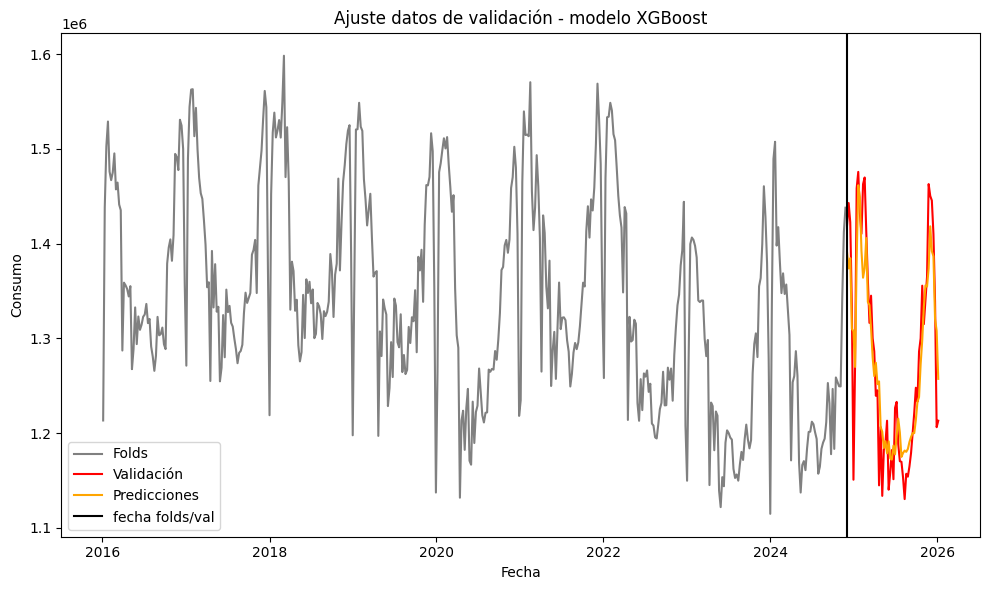

In [44]:
# ajute visual 
plt.figure(figsize=(10,6))
plt.plot(X_folds.index, y_folds , label="Folds", color="gray")
plt.plot(X_val.index, y_val, label="Validación", color="red")
plt.plot(X_val.index[-len(y_pred):], y_pred, label="Predicciones", color="orange")
plt.axvline(X_val.index[0], label="fecha folds/val", color="black")
plt.title("Ajuste datos de validación - modelo XGBoost")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
#plt.grid(True)
plt.legend()
plt.tight_layout()

In [45]:
# gráfica en plotly
# asegurar que los índices sean fechas
X_folds.index = pd.to_datetime(X_folds.index)
X_val.index = pd.to_datetime(X_val.index)

# fecha de inicio del conjunto de validación
fecha_inicio_val = X_val.index.min()

# ============================================================
# Gráfica
# ============================================================

fig = go.Figure()

# conjunto usado en los folds
fig.add_trace(
    go.Scatter(
        x=X_folds.index,
        y=np.ravel(y_folds),
        mode="lines",
        name="Folds",
        line=dict(
            color="#7F7F7F",
            width=2
        ),
        opacity=0.9
    )
)

# valores reales del conjunto de validación
fig.add_trace(
    go.Scatter(
        x=X_val.index,
        y=np.ravel(y_val),
        mode="lines",
        name="Validación",
        line=dict(
            color="#202020",
            width=2.5
        )
    )
)

# predicciones de XGBoost
fig.add_trace(
    go.Scatter(
        x=X_val.index[-len(y_pred):],
        y=np.ravel(y_pred),
        mode="lines",
        name="Predicción XGBoost",
        line=dict(
            color="#C00000",
            width=2.5
        )
    )
)

# línea de separación entre folds y validación
fig.add_vline(
    x=fecha_inicio_val,
    line_color="#555555",
    line_width=1.2,
    line_dash="dash"
)

# etiqueta de inicio de validación
fig.add_annotation(
    x=fecha_inicio_val,
    y=0.98,
    yref="paper",
    text="Inicio del conjunto de validación",
    showarrow=False,
    xanchor="left",
    yanchor="top",
    xshift=6,
    font=dict(
        family="Arial",
        size=12,
        color="#444444"
    ),
    bgcolor="rgba(255,255,255,0.85)"
)

# ============================================================
# Formato general
# ============================================================

fig.update_layout(
    width=1100,
    height=620,

    title=dict(
        text="Ajuste sobre el conjunto de validación - XGBoost",
        x=0.5,
        xanchor="center"
    ),

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color="#222222"
    ),

    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.18,
        xanchor="center",
        x=0.5,
        font=dict(size=12),
        title_text=""
    ),

    margin=dict(
        l=90,
        r=30,
        t=70,
        b=110
    ),

    hovermode="x unified"
)

# eje X
fig.update_xaxes(
    title=dict(
        text="Fecha",
        font=dict(size=17)
    ),
    tickfont=dict(size=12),
    tickformat="%Y-%m",
    dtick="M12",
    showgrid=True,
    gridcolor="#E5E5E5",
    gridwidth=1,
    showline=True,
    linecolor="#777777",
    linewidth=1,
    automargin=True
)

# eje Y
fig.update_yaxes(
    title=dict(
        text="Consumo energético (MWh)",
        font=dict(size=17)
    ),
    tickfont=dict(size=12),
    tickformat=".3s",
    showgrid=True,
    gridcolor="#D9D9D9",
    gridwidth=1,
    showline=True,
    linecolor="#777777",
    linewidth=1,
    automargin=True
)

fig.show()

fig.write_image(
    "../../../data/preds_energy_models/images/ajuste_xgboost.png",
    width=1100,
    height=620,
    scale=3
)

Se exportan las predicciones en json para poder calcular luego la predicción conjunta

In [46]:
folds_data_size = int(len(df_data_close) * 0.9) 
df_data_close[folds_data_size:]["Start date"]

517   2024-12-02
518   2024-12-09
519   2024-12-16
520   2024-12-23
521   2024-12-30
522   2025-01-06
523   2025-01-13
524   2025-01-20
525   2025-01-27
526   2025-02-03
527   2025-02-10
528   2025-02-17
529   2025-02-24
530   2025-03-03
531   2025-03-10
532   2025-03-17
533   2025-03-24
534   2025-03-31
535   2025-04-07
536   2025-04-14
537   2025-04-21
538   2025-04-28
539   2025-05-05
540   2025-05-12
541   2025-05-19
542   2025-05-26
543   2025-06-02
544   2025-06-09
545   2025-06-16
546   2025-06-23
547   2025-06-30
548   2025-07-07
549   2025-07-14
550   2025-07-21
551   2025-07-28
552   2025-08-04
553   2025-08-11
554   2025-08-18
555   2025-08-25
556   2025-09-01
557   2025-09-08
558   2025-09-15
559   2025-09-22
560   2025-09-29
561   2025-10-06
562   2025-10-13
563   2025-10-20
564   2025-10-27
565   2025-11-03
566   2025-11-10
567   2025-11-17
568   2025-11-24
569   2025-12-01
570   2025-12-08
571   2025-12-15
572   2025-12-22
573   2025-12-29
574   2026-01-05
Name: Start da

In [47]:
arr_preds = []
for index, value in enumerate(df_data_close[folds_data_size:]["Start date"]):
    dict_pred = {
        "Date": value.strftime("%Y-%m-%d"), # convierte a la fecha a string para poder exportar a json
        "pred" : float(y_pred[index])
    }
    arr_preds.append(dict_pred)
arr_preds

[{'Date': '2024-12-02', 'pred': 1390645.25},
 {'Date': '2024-12-09', 'pred': 1373664.875},
 {'Date': '2024-12-16', 'pred': 1384503.875},
 {'Date': '2024-12-23', 'pred': 1310087.5},
 {'Date': '2024-12-30', 'pred': 1307360.0},
 {'Date': '2025-01-06', 'pred': 1269734.625},
 {'Date': '2025-01-13', 'pred': 1383025.25},
 {'Date': '2025-01-20', 'pred': 1461497.875},
 {'Date': '2025-01-27', 'pred': 1448955.625},
 {'Date': '2025-02-03', 'pred': 1392504.875},
 {'Date': '2025-02-10', 'pred': 1363926.0},
 {'Date': '2025-02-17', 'pred': 1373820.0},
 {'Date': '2025-02-24', 'pred': 1405802.375},
 {'Date': '2025-03-03', 'pred': 1338161.5},
 {'Date': '2025-03-10', 'pred': 1335074.5},
 {'Date': '2025-03-17', 'pred': 1310422.0},
 {'Date': '2025-03-24', 'pred': 1279894.25},
 {'Date': '2025-03-31', 'pred': 1260047.0},
 {'Date': '2025-04-07', 'pred': 1274148.0},
 {'Date': '2025-04-14', 'pred': 1251550.0},
 {'Date': '2025-04-21', 'pred': 1254489.125},
 {'Date': '2025-04-28', 'pred': 1206286.25},
 {'Date': '2

In [48]:
# Cálculo de métricas agregadas
dict_to_export = {
    "mape_val": float(mape_val),
    "mae_val": float(mae_val),
    "smape_val": float(smape_val),
    "rmse_val": float(rmse_val),
    "predictions": arr_preds
}
with open ("../../../data/preds_energy_models/xgboost_preds_v2.json", "w") as json_file:
    json.dump(dict_to_export, json_file, indent=4)